In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [80]:
model_path = "models/finetuned_9_bandit_2"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

df = pd.read_csv("data/validation_emotions.csv")

texts = df["title"].tolist()
labels = df["label"].tolist()

encodings = tokenizer(texts, truncation=True, padding=True, return_tensors="pt")

with torch.no_grad():
    outputs = model(**encodings)
    logits = outputs.logits

preds = torch.argmax(logits, dim=1).numpy()

acc = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average="weighted")
precision = precision_score(labels, preds, average="weighted")
recall = recall_score(labels, preds, average="weighted")

print("Accuracy:", acc)
print("F1:", f1)
print("Precision:", precision)
print("Recall:", recall)

In [2]:
from labeling import Labeling
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [21]:
def evaluate(labeling_llm, df):
    y_true = df["label"]
    y_pred = df["predicted_label"]
    classes = sorted(df["label"].unique())
    print(labeling_llm)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred, average='macro'):.4f}")
    for cls in classes:
        f1 = f1_score(y_true, y_pred, average=None, labels=[cls])[0]
        print(f"F1 class {cls}: {f1:.4f}")
    
def show_llm_baseline_scores_on_validation_data(labeling_llm, n_rows=2000, verbose=False):
    task = 'emotions'
    labeler = Labeling(label_model=labeling_llm, task=task)
    
    sample_data = pd.read_csv('data/validation_emotions.csv').iloc[:n_rows]
    sample_data['clean_title'] = sample_data['title']
    
    df = labeler.generate_inference_data(sample_data, 'clean_title')
    df["llm_response"] = labeler.get_llm_responses_parallel(df, verbose)
    df['predicted_label'] = df['llm_response'].map(labeler.task_pairings[task])

    evaluate(labeling_llm, df)

In [18]:
show_llm_baseline_scores_on_validation_data('llama3:8b')

[########################################] | 100% Completed | 300.49 s
Finished parallel LLM querying in 5.021227137247721
llama3:8b
Accuracy:  0.4250
Precision: 0.4326  (weighted: 0.5624)
Recall:    0.4613  (weighted: 0.4250)
F1:        0.4012  (weighted: 0.4472)

Per-class F1:
  0: 0.4417
  1: 0.4874
  2: 0.4680
  3: 0.2940
  4: 0.4898
  5: 0.2263


In [19]:
show_llm_baseline_scores_on_validation_data('granite4.1:8b')

[########################################] | 100% Completed | 292.29 s
Finished parallel LLM querying in 4.882522424062093
granite4.1:8b
Accuracy:  0.5755
Precision: 0.5228  (weighted: 0.6109)
Recall:    0.5169  (weighted: 0.5755)
F1:        0.4895  (weighted: 0.5775)

Per-class F1:
  0: 0.5316
  1: 0.4880
  2: 0.7060
  3: 0.2930
  4: 0.6006
  5: 0.3176


In [20]:
show_llm_baseline_scores_on_validation_data('glm4:9b')

[########################################] | 100% Completed | 310.06 s
Finished parallel LLM querying in 5.1843317667643225
glm4:9b
Accuracy:  0.6295
Precision: 0.6018  (weighted: 0.6603)
Recall:    0.5859  (weighted: 0.6295)
F1:        0.5789  (weighted: 0.6349)

Per-class F1:
  0: 0.6077
  1: 0.6196
  2: 0.6834
  3: 0.4232
  4: 0.6878
  5: 0.4516


Batches:   0%|          | 0/500 [00:00<?, ?it/s]

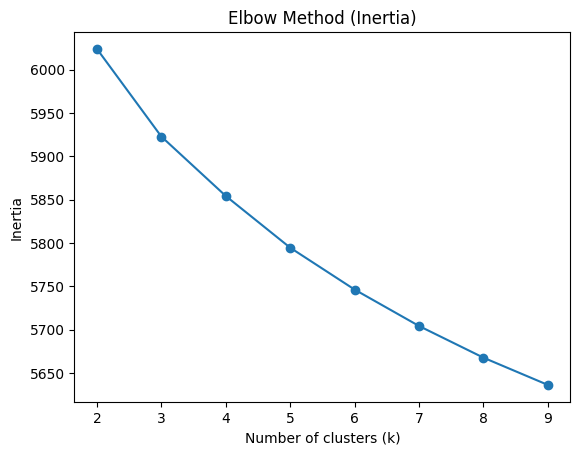

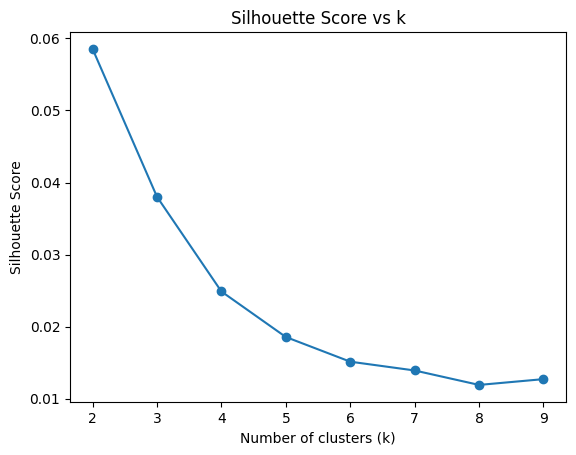

Best k by silhouette: 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import pandas as pd

model = SentenceTransformer("BAAI/bge-large-en-v1.5")

df = pd.read_csv('data/training_emotions.csv')
texts = df['title'].astype(str).tolist()

embeddings = model.encode(texts, show_progress_bar=True)
embeddings = normalize(embeddings)

ks = range(2, 10)

inertias = []
silhouettes = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(embeddings, labels))

# --- Plot Elbow (Inertia) ---
plt.figure()
plt.plot(ks, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

# --- Plot Silhouette Score ---
plt.figure()
plt.plot(ks, silhouettes, marker='o')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# Print best k by silhouette
best_k = ks[np.argmax(silhouettes)]
print("Best k by silhouette:", best_k)

In [4]:
kmeans = KMeans(n_clusters=5)
df['label_cluster'] = kmeans.fit_predict(embeddings)
df.groupby(['label', 'label_cluster']).size().unstack(fill_value=0)

C:\Users\Forle\Documents\LTS-main\LTS-main\venv\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


label_cluster,0,1,2,3,4
label,,,,,
0,131,545,98,307,1078
1,98,371,100,1213,155
2,1904,412,2097,666,283
3,717,82,171,176,158
4,268,1828,236,675,1659
5,140,97,85,211,39
